In [5]:
import os

# Clone ECP repository if not already cloned
if not os.path.exists("ECP"):
    os.system("git clone https://github.com/fouratifares/ECP.git")

In [2]:
cd ECP

/content/ECP


In [3]:
from optimizers.ECP import ECP
import numpy as np
import matplotlib.pyplot as plt

# ECP on Implemented Functions


In [4]:
# List the available functions
ls ./functions

SyntaxError: invalid syntax (2728062669.py, line 2)

The Global Search is Completed
Best Point: [ 0.05812144 -0.72617123]
Maximum Value: 1.025731113152134




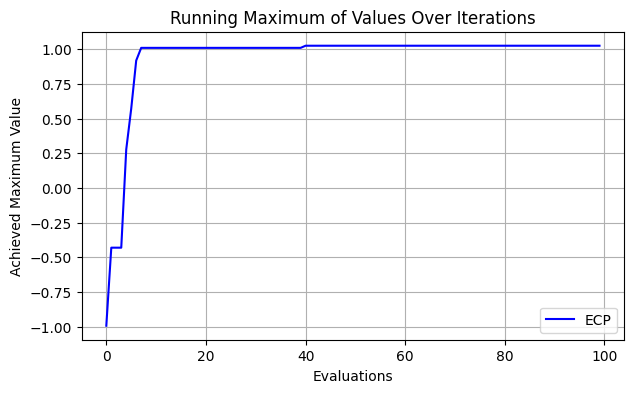

In [ ]:
# Import Camel function from /functions
from functions.camel import Function

f = Function()
points, values, epsilons = ECP(f, n = 100)

# Retrieve the corresponding point
best_point = points[np.argmax(values)]

print("The Global Search is Completed")
print("Best Point:", best_point)
print("Maximum Value:", max(values))
print("\n")

# Compute running maximum
running_max = np.maximum.accumulate(values)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(running_max, label="ECP", color="blue")
plt.xlabel("Evaluations")
plt.ylabel("Achieved Maximum Value")
plt.title("Running Maximum of Values Over Iterations")
plt.legend()
plt.grid()
plt.show()

# Multi-Objective Lipschitz Optimization Experiments
### Numerical Evaluation for Aligned Multi-Objective ECP

This notebook implements and evaluates a **multi-objective extension of Lipschitz global optimization algorithms**, inspired by:

- **Aligned Multi-Objective Optimization (AMOO)**
- **Every Call is Precious (ECP)** global optimization

The goal is to understand whether **alignment between objectives can accelerate black-box global optimization**.

---

## 1. Background

### Multi-Objective Optimization

In multi-objective optimization we optimize

$$
F(x) = (f_1(x), \dots, f_m(x))
$$

instead of a single function.

Traditional work focuses on **Pareto frontiers**, where objectives conflict.

However, in many machine learning systems objectives are **not conflicting**, but rather **aligned**:

- multi-task learning
- proxy objectives
- auxiliary RL rewards
- multiple evaluation metrics

This motivates the **Aligned Multi-Objective Optimization (AMOO)** framework.

---

## 2. Alignment Assumption

AMOO assumes that all objectives share a common optimum:

$$
x^\star \in \arg\min f_i(x) \quad \forall i
$$

This means multiple objectives describe the **same underlying solution** but with different curvature or informativeness.

---

## 3. What AMOO Actually Tested

AMOO **did not** test black-box optimization benchmarks.

Instead, they constructed synthetic objective families where:

- all objectives share the **same optimal point**
- curvature varies between objectives

Their experiments focused on two key synthetic scenarios.

### 3.1 Selection Example

Their toy objectives were defined through a shared target network output and losses of the form

$$
f_i(\theta) =
\frac{1}{|D|}
\sum_{x \in D}
\left(
(h_\theta(x) - h_{\theta^\star}(x))^\top
H_i
(h_\theta(x) - h_{\theta^\star}(x))
\right)^{\alpha_i}.
$$

Key idea:

- some objectives are more informative than others
- some objectives are relatively flatter or weaker
- the algorithm should learn to emphasize the most useful objective

Parameters varied in the experiments:

- exponent $\alpha_i$
- positive definite matrix $H_i$

Purpose:

to test whether AMOO algorithms can **adaptively focus on the most informative objective**.

### 3.2 Curvature Example

AMOO also studied a setting where curvature varies across objectives while keeping the same optimum.

Some objectives were:

- highly curved and informative in certain regions
- flatter and less informative in other regions

Goal:

to test whether AMOO algorithms can exploit curvature differences to accelerate convergence.

---

## 4. Key Limitation of AMOO Experiments

AMOO experiments **did not evaluate black-box global optimization problems**.

Instead they focused on **structured differentiable objectives with gradient access**.

This leaves an open question:

> Can alignment also accelerate **black-box global optimization**?

---

## 5. Our Setting

We study **Aligned Multi-Objective Lipschitz Optimization**.

Assume

$$
f_1, \dots, f_m \in \mathrm{Lip}(L_i)
$$

and

$$
x^\star \in \arg\min f_i(x)
\quad \text{for all objectives } i.
$$

Each objective may have a different Lipschitz constant.

---

## 6. Algorithmic Idea

The classical **ECP algorithm** maintains a Lipschitz envelope to determine whether a candidate point is worth evaluating.

We extend this idea to multiple aligned objectives.

### Multi-Objective Acceptance Region

For each objective $i$, define

$$
A_{i,t}
=
\left\{
x :
\max_j \bigl(f_i(x_j) - \epsilon_{i,t}\|x-x_j\|\bigr)
\le
\min_j f_i(x_j)
\right\}.
$$

The **multi-objective acceptance region** is the intersection

$$
A_t = \bigcap_i A_{i,t}.
$$

A point is evaluated only if it is **promising for every objective**.

---

## 7. Experimental Design

We perform black-box experiments similar in spirit to AMOO, but adapted to global optimization.

### Base benchmark functions

We use standard global optimization benchmarks:

- Camel
- Hartmann
- Rastrigin
- Himmelblau
- Rosenbrock

These come from the ECP benchmark suite.

---

## 8. Generating Aligned Objectives

To create aligned objectives we transform a base function $g(x)$.

### Exact alignment

$$
f_i(x) = \phi_i(g(x))
$$

where $\phi_i$ is monotone.

This preserves the same optimizer.

### Approximate alignment

$$
f_i(x) = g(x) + \delta_i h_i(x)
$$

where $h_i(x)$ is a small perturbation term.

This simulates **realistic imperfect alignment**.

---

## 9. Baselines

We compare against several standard approaches:

1. **Single-objective ECP**
2. **Equal-weight scalarization**

$$
f(x) = \frac{1}{m}\sum_i f_i(x)
$$

3. **Lexicographic optimization**
4. **Random search**

---

## 10. Metrics

We evaluate performance using **worst-objective regret**:

$$
R(n)
=
\max_i
\left(
\min_x f_i(x)
-
\min_{j \le n} f_i(x_j)
\right).
$$

This measures how well the algorithm solves **all objectives simultaneously**.

---

## 11. Goal of These Experiments

The experiments test the hypothesis:

> If objectives are aligned, exploiting multiple objectives should reduce the search space faster than optimizing any single objective.

This notebook implements the algorithms and runs the benchmark experiments.

---


In [ ]:
import numpy as np


def Uniform(X: np.array):
    """
    Generates a random point within the feasible region X.

    X: The feasible region (numpy array).
    """

    theta = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        theta[i] = np.random.uniform(X[i, 0], X[i, 1])
    return theta


def growth_condition(last_nb_samples, max_slope):
    """
    Checks whether the slope of the last points of the nb_samples vs. nb_evaluations curve exceeds max_slope.
    """
    slope = (last_nb_samples[-1] - last_nb_samples[0]) / (len(last_nb_samples) - 1)
    return slope > max_slope


def acceptance_condition(x, values, epsilon, points, strict=False):
    """
    Verifies the acceptance condition based on the current values and explored points.

    values: Array of function values from previously explored points (numpy array).
    x: The point to be evaluated (numpy array).
    epsilon: A small value used for the condition (float).
    points: The set of previously explored points (numpy array).
    strict: Whether the condition should be strictly greater (bool).
    """
    max_val = np.max(values)
    left_min = np.min(values + epsilon * np.linalg.norm(x - points, ord=2, axis=1))

    if strict:
        return left_min > max_val
    else:
        return left_min >= max_val

In [7]:
!sed -n '1,220p' /content/ECP/utils/runs.py


import argparse
import os
import numpy as np
import time
from optimizers.ECP import ECP
from optimizers.ECPv2 import ECPv2


def convert_to_function(name):
    """
    Converts a function name (string) into the actual function reference.

    Args:
    - name: The name of the function as a string.

    Returns:
    - A list containing the corresponding function reference.
    """

    functions = []

    if name in globals():
        functions.append(globals()[name])
    else:
        raise ValueError(f"'{name}' is not defined or imported.")

    return functions


def cli():
    """Parses command-line arguments."""
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--function", "-f", type=str, help="Function to maximize", required=True
    )
    parser.add_argument(
        "--n_eval", "-n", type=int, help="Number of evaluations (budget)", required=True
    )
    parser.add_argument("--n_run", "-r", type=int, help="Number of runs", required=True)
    parser.add_a

In [6]:
#gets the original ECP algorithm
!sed -n '1,220p' /content/ECP/utils/utils.py


import numpy as np


def Uniform(X: np.array):
    """
    Generates a random point within the feasible region X.

    X: The feasible region (numpy array).
    """

    theta = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        theta[i] = np.random.uniform(X[i, 0], X[i, 1])
    return theta


def growth_condition(last_nb_samples, max_slope):
    """
    Checks whether the slope of the last points of the nb_samples vs. nb_evaluations curve exceeds max_slope.
    """
    slope = (last_nb_samples[-1] - last_nb_samples[0]) / (len(last_nb_samples) - 1)
    return slope > max_slope


def acceptance_condition(x, values, epsilon, points, strict=False):
    """
    Verifies the acceptance condition based on the current values and explored points.

    values: Array of function values from previously explored points (numpy array).
    x: The point to be evaluated (numpy array).
    epsilon: A small value used for the condition (float).
    points: The set of previously explored points

In [9]:
!sed -n '1,220p' /content/ECP/optimizers/ECP.py


from collections import deque
from utils.utils import *
import numpy as np


def ECP(f, n: int, epsilon=1e-2, tau_=1.001, C=1000):
    """
    f: The class of the function to be maximized (class)
    n: The number of function evaluations (int)
    epsilon: A small value (epsilon_1 > 0)
    tau_: A scaling factor (tau_ > 1)
    C: A constant (C > 1)
    """

    # Initialize variables
    t = 1
    tau = max(1 + (1 / (n * f.dimensions)), tau_)

    # Generate the first random point
    X_1 = Uniform(f.bounds)
    nb_samples = 1

    # Track the number of samples in the last step
    last_nb_samples = deque([1], maxlen=2)

    # Initialize the points and corresponding function values
    points = X_1.reshape(1, -1)
    values = np.array([f(X_1)])

    # Store the current epsilon value
    epsilons = [epsilon]

    # Main optimization loop
    while t < n:
        count_inner_growth = 0
        while True:
            # Generate the next random point
            X_tp1 = Uniform(f.bounds)


In [ ]:
acceptance_condition_mo

In [ ]:
from collections import deque
from utils.utils import *
import numpy as np


def ECP(f, n: int, epsilon=1e-2, tau_=1.001, C=1000):
    """
    f: The class of the function to be maximized (class)
    n: The number of function evaluations (int)
    epsilon: A small value (epsilon_1 > 0)
    tau_: A scaling factor (tau_ > 1)
    C: A constant (C > 1)
    """

    # Initialize variables
    t = 1
    tau = max(1 + (1 / (n * f.dimensions)), tau_)

    # Generate the first random point
    X_1 = Uniform(f.bounds)
    nb_samples = 1

    # Track the number of samples in the last step
    last_nb_samples = deque([1], maxlen=2)

    # Initialize the points and corresponding function values
    points = X_1.reshape(1, -1)
    values = np.array([f(X_1)])

    # Store the current epsilon value
    epsilons = [epsilon]

    # Main optimization loop
    while t < n:
        count_inner_growth = 0
        while True:
            # Generate the next random point
            X_tp1 = Uniform(f.bounds)
            nb_samples += 1
            last_nb_samples[-1] = nb_samples

            # Check if the point satisfies the acceptance condition
            if acceptance_condition(X_tp1, values, epsilon, points, strict=False):
                points = np.concatenate((points, X_tp1.reshape(1, -1)))
                break

            # Check if the growth condition is met
            elif growth_condition(last_nb_samples, C):
                count_inner_growth += 1
                epsilon *= tau
                last_nb_samples[-1] = 0

        # Evaluate the function at the new point
        value = f(X_tp1)
        t += 1
        epsilon *= tau
        epsilons.append(epsilon)

        # Add the new point and its value to the results
        values = np.concatenate((values, np.array([value])))

        # Reset the sample count for the next iteration
        last_nb_samples.append(0)

    return points, values, np.array(epsilons)


Testing 2 functions

In [10]:
import numpy as np

class AlignedCamel2Obj:
    def __init__(self):
        self.bounds = np.array([[-2.0, 2.0], [-1.5, 1.5]])

    def base(self, x):
        x1, x2 = x
        return (
            2 * x1**2
            - 1.05 * x1**4
            + (x1**6) / 6
            + x1 * x2
            + x2**2
        )

    def evaluate(self, x):
        g = -self.base(x)   # convert to maximization if needed
        f1 = g
        f2 = np.tanh(g)
        return np.array([f1, f2])

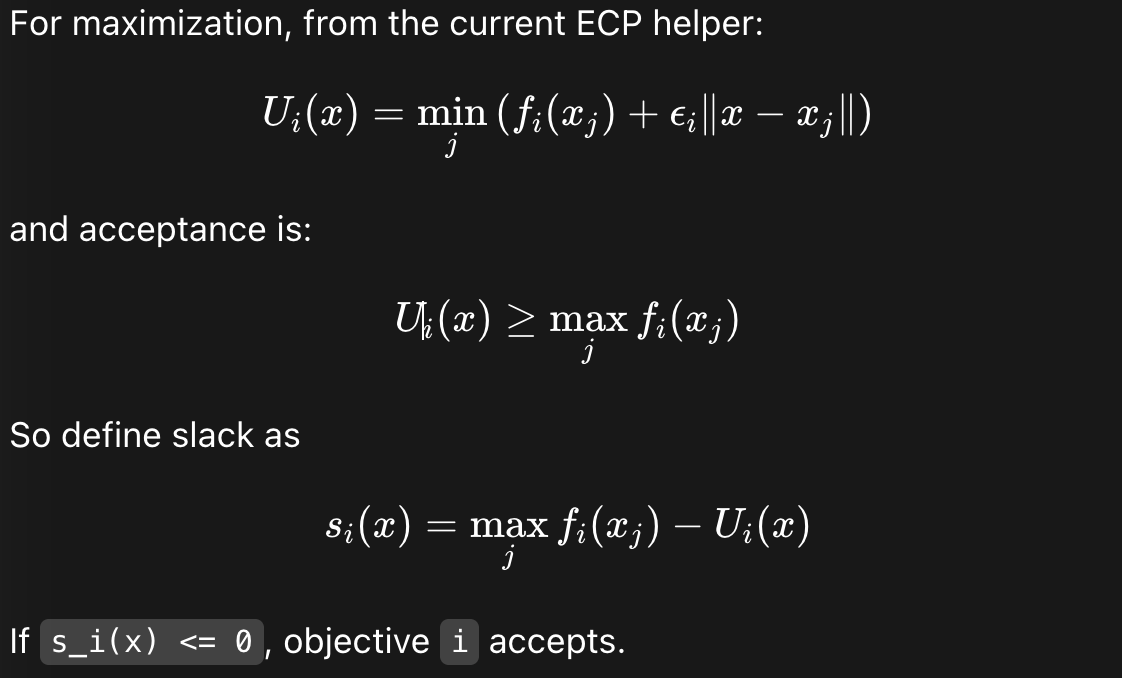

Remark: our objective violation is defined in the maximization regime, and this is translated to match ECP's maximization

 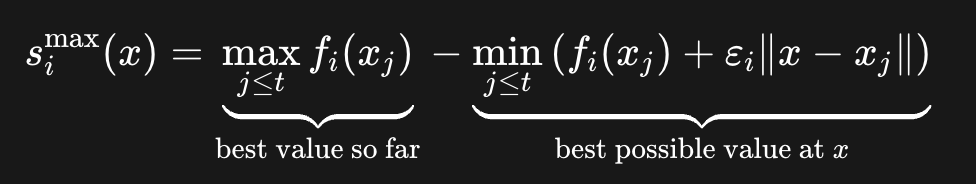

In [11]:
def objective_slacks(x, points, values_list, epsilons):
    slacks = []
    for i in range(len(values_list)):
        values = np.array(values_list[i])
        eps = epsilons[i]
        upper_env = np.min(values + eps * np.linalg.norm(x - points, axis=1))
        slack = np.max(values) - upper_env
        slacks.append(slack)
    return np.array(slacks)


def most_blocking_objective(x, points, values_list, epsilons):
    slacks = objective_slacks(x, points, values_list, epsilons)
    return int(np.argmax(slacks)), slacks

def acceptance_condition_mo(x, points, values_list, epsilons):
    slacks = objective_slacks(x, points, values_list, epsilons)
    return np.all(slacks <= 0), slacks

In [12]:
def MO_ECP(f, n=50, epsilon_init=1e-2, tau=1.05, max_rejects=100):
    X = f.bounds
    m = len(f.evaluate(Uniform(X)))

    x1 = Uniform(X)
    y1 = f.evaluate(x1)

    points = [x1]
    values_list = [[y1[i]] for i in range(m)]
    epsilons = np.full(m, epsilon_init, dtype=float)
    reject_counts = np.zeros(m, dtype=int)

    while len(points) < n:
        x = Uniform(X)
        accepted, slacks = acceptance_condition_mo(
            x,
            np.array(points),
            values_list,
            epsilons
        )

        if accepted:
            y = f.evaluate(x)
            points.append(x)
            for i in range(m):
                values_list[i].append(y[i])
            reject_counts[:] = 0
        else:
            i_star = int(np.argmax(slacks))
            reject_counts[i_star] += 1

            if reject_counts[i_star] >= max_rejects:
                epsilons[i_star] *= tau
                reject_counts[i_star] = 0

    return np.array(points), [np.array(v) for v in values_list], epsilons

In [21]:
import numpy as np

def Uniform(bounds):
    bounds = np.asarray(bounds)
    lows = bounds[:, 0]
    highs = bounds[:, 1]
    return np.random.uniform(lows, highs)
f = AlignedCamel2Obj()
points, values_list, eps = MO_ECP(f, n=2000, epsilon_init=1e-2, tau=1.1, max_rejects=20)

print("num points:", len(points))
print("final eps:", eps)
print("best f1:", np.max(values_list[0]))
print("best f2:", np.max(values_list[1]))

num points: 2000
final eps: [24.7856426  12.71895371]
best f1: -0.0003155877935911708
best f2: -0.00031558778311411347


In [22]:
import numpy as np

best = np.array(points)[np.argmax(values_list[0])]
print(best)

[-0.0130239   0.00217844]


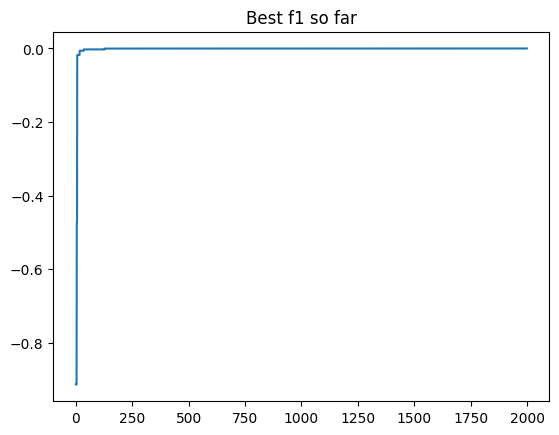

In [23]:
plt.plot(np.maximum.accumulate(values_list[0]))
plt.title("Best f1 so far")
plt.show()